# 📈 StockSense — Production Sentiment Analysis

**Real pipeline on your `stockMentionsTWITTER.json`**

| Stage | Details |
|---|---|
| Data | 80 000+ real tweets across 25 tickers |
| Labelling | Financial lexicon → confidence filtering → pseudo-label self-training |
| Model | BiLSTM + GRU ensemble with multi-head attention (custom, zero pretrained weights) |
| Training | ~30–40 min on T4 GPU, OneCycleLR + label smoothing + gradient clipping |
| Output | Interactive HTML dashboard (open without a server) |

---
**Runtime → Change runtime type → T4 GPU** before running.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — Install
# ══════════════════════════════════════════════════════════════════
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas numpy tqdm matplotlib seaborn

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — Imports & reproducibility
# ══════════════════════════════════════════════════════════════════
import os, json, re, math, time, random, copy
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — Config  (tune here)
# ══════════════════════════════════════════════════════════════════
CFG = dict(
    # ── data ──
    json_path        = '/content/drive/MyDrive/stockMentionsTWITTER.json',
    min_tweet_len    = 5,          # tokens; shorter tweets discarded
    max_seq_len      = 80,         # truncate / pad to this
    min_vocab_freq   = 3,          # vocab threshold
    test_size        = 0.15,
    val_size         = 0.10,

    # ── labelling ──
    # confidence threshold for pseudo-label self-training round
    pseudo_conf_thr  = 0.80,

    # ── model ──
    embed_dim        = 256,
    lstm_hidden      = 384,
    gru_hidden       = 256,
    num_lstm_layers  = 3,
    num_gru_layers   = 2,
    num_attn_heads   = 4,
    dropout          = 0.40,
    num_classes      = 3,          # 0=Neg 1=Neu 2=Pos

    # ── training ──
    batch_size       = 128,
    epochs_warmup    = 5,          # initial training on high-confidence labels
    epochs_self      = 10,         # self-training rounds
    epochs_finetune  = 8,          # final fine-tune on full pseudo-labeled set
    lr               = 2e-3,
    weight_decay     = 1e-4,
    grad_clip        = 1.0,
    label_smoothing  = 0.10,
    patience         = 4,          # early stopping patience
)

LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
print('Config ready.')

Config ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — Upload your JSON  (run once)
# ══════════════════════════════════════════════════════════════════
from google.colab import files
print('Upload stockMentionsTWITTER.json …')
uploaded = files.upload()           # pick your file
fname = list(uploaded.keys())[0]
os.rename(fname, CFG['json_path'])
print(f'Saved to {CFG["json_path"]}')

Upload stockMentionsTWITTER.json …


KeyboardInterrupt: 

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — Load & flatten JSON
# ══════════════════════════════════════════════════════════════════
with open(CFG['json_path'], 'r', errors='replace') as f:
    raw_data = json.load(f)

rows = []
for ticker, tweets in raw_data.items():
    for text in tweets:
        if isinstance(text, str) and text.strip():
            rows.append({'ticker': ticker, 'text': text.strip()})

df = pd.DataFrame(rows)
print(f'Total tweets loaded : {len(df):,}')
print(f'Tickers ({len(df.ticker.unique())}) : {sorted(df.ticker.unique())}')
print()
print(df.ticker.value_counts().to_string())

Total tweets loaded : 80,793
Tickers (25) : ['AAPL', 'AMD', 'AMZN', 'BA', 'BX', 'COST', 'CRM', 'DIS', 'ENPH', 'F', 'GOOG', 'INTC', 'KO', 'META', 'MSFT', 'NFLX', 'NIO', 'NOC', 'PG', 'PYPL', 'TSLA', 'TSM', 'VZ', 'XPEV', 'ZS']

ticker
TSLA    37422
TSM     11034
AAPL     5056
AMZN     4089
MSFT     4089
PG       4089
NIO      3021
META     2751
AMD      2227
NFLX     1727
GOOG     1291
PYPL      843
DIS       635
BA        399
COST      393
INTC      315
KO        310
CRM       233
XPEV      225
ENPH      216
ZS        193
VZ        123
BX         50
F          31
NOC        31


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — Text cleaning & tokenisation
# ══════════════════════════════════════════════════════════════════
# Financial-domain stopwords (keep cashtags, negations, numbers)
STOPWORDS = frozenset([
    'the','a','an','and','or','but','in','on','at','to','for','of',
    'is','it','this','that','was','are','be','been','have','has',
    'with','by','from','as','will','we','he','she','they','our',
    'their','my','can','do','so','if','all','its','also','than',
    'then','what','which','who','about','out','after','before',
    'into','up','more','some','any','here','there','would','could',
    'should','may','might','must','shall','very','just','even','still',
    'each','both','few','those','these','such','same','own','other',
    'when','where','how','much','many','most','been','being','am',
])

# Emoji shortcodes → keep as semantic tokens
EMOJI_MAP = {
    ':rocket:': ' rocket ',  ':fire:': ' fire ',
    ':up_arrow:': ' up ',    ':down_arrow:': ' down ',
    ':red_heart:': ' love ', ':eyes:': ' watch ',
    ':pile_of_poo:': ' bad ',':light_bulb:': ' idea ',
    ':chart_increasing:': ' gain ', ':chart_decreasing:': ' loss ',
    ':money_bag:': ' money ', ':bear:': ' bear ',
    ':bull:': ' bull ',
}

def clean(text: str) -> str:
    for k, v in EMOJI_MAP.items():
        text = text.replace(k, v)
    text = re.sub(r'http\S+|www\S+', ' url ', text)     # URL → token
    text = re.sub(r'@\w+', ' user ', text)               # mentions
    text = re.sub(r'\$([A-Za-z]+)', r' TICK_\1 ', text)  # $TSLA → TICK_TSLA
    text = re.sub(r'#(\w+)', r' TAG_\1 ', text)          # hashtags
    text = re.sub(r'[^a-zA-Z0-9_\s]', ' ', text)        # strip punctuation
    text = re.sub(r'\b(\d+)\b', ' NUM ', text)           # numbers → NUM
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def tokenize(text: str) -> list:
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

print('Cleaning …')
df['clean']  = df['text'].apply(clean)
df['tokens'] = df['clean'].apply(tokenize)
df['length'] = df['tokens'].apply(len)

before = len(df)
df = df[df['length'] >= CFG['min_tweet_len']].reset_index(drop=True)
print(f'After length filter : {len(df):,}  (removed {before - len(df):,} short tweets)')

# De-duplicate on cleaned text
df = df.drop_duplicates('clean').reset_index(drop=True)
print(f'After de-dup        : {len(df):,}')

Cleaning …
After length filter : 77,606  (removed 3,187 short tweets)
After de-dup        : 61,098


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 — Financial lexicon (expanded, domain-specific)
# ══════════════════════════════════════════════════════════════════
POS = frozenset([
    # Bullish / gains
    'bull','bullish','long','buy','buying','bought','hold','holding',
    'gain','gains','profit','profits','profit','rally','rallies',
    'surge','surges','surging','soar','soars','soaring',
    'beat','beats','exceed','exceeds','outperform','outperforms',
    'upgrade','upgraded','upside','breakout','momentum','strong',
    'stronger','record','high','highs','all_time_high','ath',
    'growth','growing','expand','expansion','revenue','revenue_beat',
    'eps_beat','innovation','innovative','disruption','disruptive',
    'moon','rocket','fire','undervalued','cheap','bargain','dip',
    'opportunity','potential','promising','confident','confidence',
    'love','great','excellent','amazing','incredible','impressive',
    'win','winning','winner','best','top','leading','dominant',
    'positive','optimistic','optimism','green','up',
    # Financials
    'dividend','dividends','buyback','buybacks','eps','guidance_raised',
    'raised','raise','raising','margin','margins','cashflow','free_cash',
])

NEG = frozenset([
    # Bearish / losses
    'bear','bearish','short','sell','selling','sold','dump','dumping',
    'loss','losses','decline','declines','declining','drop','drops',
    'fall','falls','falling','crash','crashes','crashing','plunge',
    'miss','misses','missed','disappoint','disappoints','disappointed',
    'downgrade','downgraded','downside','breakdown','weak','weaker',
    'low','lows','52_week_low','cut','cuts','guidance_cut','reduce',
    'reduced','layoff','layoffs','fired','bankruptcy','bankrupt',
    'fraud','scandal','lawsuit','probe','investigation','regulatory',
    'risk','risky','overvalued','expensive','bubble','bloated',
    'terrible','awful','horrible','bad','worst','avoid','stay_away',
    'problem','problems','issue','issues','concern','concerns',
    'fear','panic','red','down','negative','pessimistic','pessimism',
    # Financials
    'debt','debts','leverage','margin_call','dilution','dilute',
    'eps_miss','revenue_miss','guidance_miss','writedown','impairment',
])

NEGATION = frozenset(['not','no','never','neither','nor','without',
                       'cant','cannot','wont','wouldnt','shouldnt',
                       'dont','doesnt','didnt','isnt','wasnt','arent'])

def lexicon_score(tokens: list) -> tuple:
    """
    Returns (pos_count, neg_count) with basic negation handling.
    A negation token flips the polarity of the next 2 sentiment words.
    """
    pos, neg = 0, 0
    negate = 0
    for t in tokens:
        if t in NEGATION:
            negate = 2
            continue
        if t in POS:
            if negate > 0: neg += 1
            else:           pos += 1
        elif t in NEG:
            if negate > 0: pos += 1
            else:           neg += 1
        if negate > 0: negate -= 1
    return pos, neg

def lexicon_label_conf(tokens: list) -> tuple:
    """
    Returns (label 0/1/2, confidence 0-1).
    Confidence is based on how lopsided the pos/neg counts are.
    """
    pos, neg = lexicon_score(tokens)
    total = pos + neg
    if total == 0:
        return 1, 0.50   # Neutral, low confidence
    ratio = max(pos, neg) / total
    # Map ratio to a tighter confidence band: [0.5 , 1.0] → [0.5, 0.95]
    conf = 0.50 + (ratio - 0.50) * 0.90
    label = 2 if pos > neg else (0 if neg > pos else 1)
    # If counts tie → neutral
    if pos == neg: label = 1
    # Tweets with zero sentiment words default to neutral with low confidence
    return label, round(conf, 3)

print('Applying lexicon labels …')
df[['label','conf']] = df['tokens'].apply(
    lambda t: pd.Series(lexicon_label_conf(t))
)

print(df['label'].value_counts().rename(LABEL_MAP))
print(f'\nMean confidence : {df.conf.mean():.3f}')
print(f'High-conf (≥0.80) : {(df.conf >= 0.80).sum():,}  '
      f'({(df.conf >= 0.80).mean()*100:.1f}%)')

Applying lexicon labels …
label
Neutral     34368
Positive    18455
Negative     8275
Name: count, dtype: int64

Mean confidence : 0.683
High-conf (≥0.80) : 23,736  (38.8%)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 8 — Vocabulary
# ══════════════════════════════════════════════════════════════════
all_tokens = [t for tokens in df['tokens'] for t in tokens]
freq = Counter(all_tokens)
vocab = ['<PAD>', '<UNK>'] + [
    w for w, c in freq.most_common() if c >= CFG['min_vocab_freq']
]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size : {VOCAB_SIZE:,}')
print(f'Top 30 tokens   : {[w for w,_ in freq.most_common(30)]}')

def encode(tokens: list, max_len: int = None) -> list:
    ml = max_len or CFG['max_seq_len']
    ids = [word2idx.get(t, 1) for t in tokens[:ml]]
    ids += [0] * (ml - len(ids))
    return ids

Vocabulary size : 17,319
Top 30 tokens   : ['num', 'user', 'url', 'tick_tsla', 'you', 'tesla', 'not', 'now', 'tick_aapl', 'today', 'tsm', 'stock', 'elon', 'tick_amzn', 'like', 'day', 'over', 'new', 'one', 'time', 'market', 'me', 'year', 'down', 'tag_tesla', 'tick_fb', 'see', 'no', 'tick_nio', 'your']


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 9 — Dataset & DataLoader helpers
# ══════════════════════════════════════════════════════════════════
class TweetDataset(Dataset):
    def __init__(self, encodings, labels, weights=None):
        self.X = torch.tensor(encodings, dtype=torch.long)
        self.y = torch.tensor(labels,    dtype=torch.long)
        self.w = weights  # optional per-sample weights

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        if self.w is not None:
            return self.X[i], self.y[i], self.w[i]
        return self.X[i], self.y[i]


def make_loaders(df_sub, shuffle=True, use_weights=False):
    enc = list(df_sub['tokens'].apply(encode))
    lbl = list(df_sub['label'])

    sampler = None
    if use_weights and shuffle:
        # Balanced sampling to fight class imbalance
        class_counts = Counter(lbl)
        w = [1.0 / class_counts[l] for l in lbl]
        sampler = WeightedRandomSampler(w, num_samples=len(w), replacement=True)
        shuffle = False  # can't use both

    ds = TweetDataset(enc, lbl)
    return DataLoader(
        ds,
        batch_size = CFG['batch_size'],
        shuffle    = shuffle,
        sampler    = sampler,
        num_workers= 2,
        pin_memory = (DEVICE == 'cuda'),
    )


# ── Initial split: high-confidence for warmup training ──
df_high = df[df['conf'] >= CFG['pseudo_conf_thr']].copy()
df_low  = df[df['conf'] <  CFG['pseudo_conf_thr']].copy()

print(f'High-confidence pool : {len(df_high):,}')
print(f'Unlabelled pool      : {len(df_low):,}')

X_tr, X_tmp = train_test_split(df_high, test_size=CFG['test_size']+CFG['val_size'],
                                random_state=SEED, stratify=df_high['label'])
X_val, X_te = train_test_split(X_tmp,   test_size=CFG['test_size']/(CFG['test_size']+CFG['val_size']),
                                random_state=SEED, stratify=X_tmp['label'])

train_loader = make_loaders(X_tr,  shuffle=True,  use_weights=True)
val_loader   = make_loaders(X_val, shuffle=False)
test_loader  = make_loaders(X_te,  shuffle=False)

print(f'Train {len(X_tr):,}  |  Val {len(X_val):,}  |  Test {len(X_te):,}')

High-confidence pool : 23,736
Unlabelled pool      : 37,362
Train 17,802  |  Val 2,373  |  Test 3,561


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 10 — Model: BiLSTM + GRU Ensemble with Multi-Head Attention
#
#  Architecture (fully custom, zero pretrained weights):
#
#  Input tokens
#      │
#  Embedding (256) + positional scale
#      │
#  ┌───┴───────────────────────────────┐
#  │ BiLSTM branch (3 layers, 384×2)  │
#  │ BiGRU  branch (2 layers, 256×2)  │
#  └───┬───────────────────────────────┘
#      │  concat → (1280,)
#  Multi-Head Attention pooling (4 heads)
#      │
#  FC 1024 → GELU → Dropout → LayerNorm
#      │
#  FC 512  → GELU → Dropout → LayerNorm
#      │
#  FC 3  (logits)
# ══════════════════════════════════════════════════════════════════

class MultiHeadAttentionPool(nn.Module):
    """Learned multi-head pooling over a sequence."""
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        assert d_model % num_heads == 0
        self.h  = num_heads
        self.dh = d_model // num_heads
        self.q  = nn.Linear(d_model, d_model)
        self.k  = nn.Linear(d_model, d_model)
        self.v  = nn.Linear(d_model, d_model)
        self.o  = nn.Linear(d_model, d_model)
        # Learnable global query (one per head)
        self.global_q = nn.Parameter(torch.randn(1, num_heads, 1, self.dh))

    def forward(self, x, mask=None):
        B, L, D = x.shape
        # Project
        K = self.k(x).view(B, L, self.h, self.dh).transpose(1, 2)  # B,h,L,dh
        V = self.v(x).view(B, L, self.h, self.dh).transpose(1, 2)
        Q = self.global_q.expand(B, -1, -1, -1)                      # B,h,1,dh

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.dh)  # B,h,1,L
        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, -1e9)
        w = torch.softmax(scores, dim=-1)                            # B,h,1,L
        ctx = torch.matmul(w, V).squeeze(2)                          # B,h,dh
        ctx = ctx.reshape(B, D)                                      # B,D
        return self.o(ctx)


class SentimentEnsemble(nn.Module):
    def __init__(self, vocab_size, cfg):
        super().__init__()
        E  = cfg['embed_dim']
        LH = cfg['lstm_hidden']
        GH = cfg['gru_hidden']
        dr = cfg['dropout']
        nc = cfg['num_classes']
        nh = cfg['num_attn_heads']

        # ── Shared embedding ──
        self.embed    = nn.Embedding(vocab_size, E, padding_idx=0)
        self.emb_drop = nn.Dropout(dr)
        # Positional scale (learnable scalar per position)
        self.pos_scale = nn.Parameter(torch.ones(1, cfg['max_seq_len'], 1))

        # ── BiLSTM branch ──
        self.lstm = nn.LSTM(
            E, LH, num_layers=cfg['num_lstm_layers'],
            bidirectional=True, batch_first=True,
            dropout=dr if cfg['num_lstm_layers'] > 1 else 0.0,
        )
        self.lstm_drop = nn.Dropout(dr)

        # ── BiGRU branch ──
        self.gru = nn.GRU(
            E, GH, num_layers=cfg['num_gru_layers'],
            bidirectional=True, batch_first=True,
            dropout=dr if cfg['num_gru_layers'] > 1 else 0.0,
        )
        self.gru_drop = nn.Dropout(dr)

        # ── Fusion attention ──
        fused_dim = LH * 2 + GH * 2   # concat of both branches
        # Make fused_dim divisible by num_heads
        pad = (nh - fused_dim % nh) % nh
        self.fuse_proj = nn.Linear(fused_dim, fused_dim + pad)
        fused_dim = fused_dim + pad
        self.attn = MultiHeadAttentionPool(fused_dim, nh)

        # ── Classifier ──
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 1024),
            nn.GELU(),
            nn.Dropout(dr),
            nn.LayerNorm(1024),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(dr),
            nn.LayerNorm(512),
            nn.Linear(512, nc),
        )
        self._init()

    def _init(self):
        nn.init.normal_(self.embed.weight, 0, 0.02)
        for name, p in self.lstm.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            else: nn.init.zeros_(p)
        for name, p in self.gru.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            else: nn.init.zeros_(p)
        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        mask = (x != 0)                           # B, L
        e  = self.emb_drop(self.embed(x))         # B, L, E
        e  = e * self.pos_scale[:, :e.size(1), :] # positional scaling

        lo, _ = self.lstm(e)                      # B, L, 2*LH
        lo     = self.lstm_drop(lo)
        go, _  = self.gru(e)                      # B, L, 2*GH
        go     = self.gru_drop(go)

        fused  = torch.cat([lo, go], dim=-1)      # B, L, 2LH+2GH
        fused  = F.gelu(self.fuse_proj(fused))    # B, L, fused_dim
        ctx    = self.attn(fused, mask)            # B, fused_dim
        return self.head(ctx)                      # B, nc


model = SentimentEnsemble(VOCAB_SIZE, CFG).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters : {total_params:,}')
print(model)

Model parameters : 25,509,203
SentimentEnsemble(
  (embed): Embedding(17319, 256, padding_idx=0)
  (emb_drop): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(256, 384, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (lstm_drop): Dropout(p=0.4, inplace=False)
  (gru): GRU(256, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (gru_drop): Dropout(p=0.4, inplace=False)
  (fuse_proj): Linear(in_features=1280, out_features=1280, bias=True)
  (attn): MultiHeadAttentionPool(
    (q): Linear(in_features=1280, out_features=1280, bias=True)
    (k): Linear(in_features=1280, out_features=1280, bias=True)
    (v): Linear(in_features=1280, out_features=1280, bias=True)
    (o): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (head): Sequential(
    (0): Linear(in_features=1280, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.4, inplace=False)
    (3): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 11 — Training utilities
# ══════════════════════════════════════════════════════════════════
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

def make_optimizer_scheduler(model, epochs, loader_len):
    opt = optim.AdamW(model.parameters(), lr=CFG['lr'],
                      weight_decay=CFG['weight_decay'])
    sched = optim.lr_scheduler.OneCycleLR(
        opt, max_lr=CFG['lr'],
        steps_per_epoch=loader_len,
        epochs=epochs,
        pct_start=0.2,
        div_factor=10,
        final_div_factor=100,
    )
    return opt, sched


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)
        logits  = model(xb)
        loss    = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total


def train_loop(model, train_loader, val_loader, epochs, tag=''):
    """Full training loop with early stopping. Returns history dict."""
    opt, sched = make_optimizer_scheduler(model, epochs, len(train_loader))
    history = {'tr_loss':[],'tr_acc':[],'vl_loss':[],'vl_acc':[]}
    best_val_acc = 0.0
    best_state   = None
    patience_ctr = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'{tag} Epoch {epoch:02d}/{epochs}', leave=False)
        for batch in pbar:
            xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            opt.step(); sched.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
            pbar.set_postfix(loss=f'{loss.item():.3f}')

        tr_loss = total_loss / total
        tr_acc  = correct / total
        vl_loss, vl_acc = evaluate(model, val_loader)

        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['vl_loss'].append(vl_loss)
        history['vl_acc'].append(vl_acc)

        print(f'{tag} Ep {epoch:02d}  '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f}  '
              f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= CFG['patience']:
                print(f'  Early stop at epoch {epoch}.')
                break

    model.load_state_dict(best_state)
    print(f'  ✅ Best val acc: {best_val_acc:.4f}\n')
    return history, best_val_acc

print('Utilities ready.')

Utilities ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 12 — Phase 1: Warmup training on high-confidence labels
# ══════════════════════════════════════════════════════════════════
print('═'*60)
print('PHASE 1 — Warmup on high-confidence lexicon labels')
print('═'*60)
hist_warmup, _ = train_loop(
    model, train_loader, val_loader,
    epochs=CFG['epochs_warmup'], tag='[Warmup]'
)

════════════════════════════════════════════════════════════
PHASE 1 — Warmup on high-confidence lexicon labels
════════════════════════════════════════════════════════════


[Warmup] Epoch 01/5:   0%|          | 0/140 [00:00<?, ?it/s]

[Warmup] Ep 01  tr_loss=0.5938 tr_acc=0.8176  vl_loss=0.3794 vl_acc=0.9772


[Warmup] Epoch 02/5:   0%|          | 0/140 [00:00<?, ?it/s]

[Warmup] Ep 02  tr_loss=0.3485 tr_acc=0.9768  vl_loss=0.3380 vl_acc=0.9869


...

[Warmup] Ep 03  tr_loss=0.3096 tr_acc=0.9934  vl_loss=0.3145 vl_acc=0.9975


[Warmup] Epoch 04/5:   0%|          | 0/140 [00:00<?, ?it/s]

[Warmup] Ep 04  tr_loss=0.2984 tr_acc=0.9972  vl_loss=0.3175 vl_acc=0.9979


[Warmup] Epoch 05/5:   0%|          | 0/140 [00:00<?, ?it/s]

[Warmup] Ep 05  tr_loss=0.2940 tr_acc=0.9993  vl_loss=0.3182 vl_acc=0.9979
  ✅ Best val acc: 0.9979



In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 13 — Phase 2: Self-training on low-confidence pool
#
#  Iteratively:
#   1. Run model on unlabelled pool
#   2. Keep predictions above threshold
#   3. Add them to training set
#   4. Re-train for a few epochs
# ══════════════════════════════════════════════════════════════════
print('═'*60)
print('PHASE 2 — Self-training on low-confidence pool')
print('═'*60)

@torch.no_grad()
def pseudo_label(model, df_unlabelled, threshold):
    """Returns df with pseudo-labels where model confidence >= threshold."""
    model.eval()
    enc  = list(df_unlabelled['tokens'].apply(encode))
    X    = torch.tensor(enc, dtype=torch.long)
    preds, confs = [], []
    for i in range(0, len(X), CFG['batch_size'] * 4):
        xb = X[i:i+CFG['batch_size']*4].to(DEVICE)
        probs = torch.softmax(model(xb), dim=-1).cpu()
        conf, pred = probs.max(dim=-1)
        preds.extend(pred.numpy())
        confs.extend(conf.numpy())
    df_unlabelled = df_unlabelled.copy()
    df_unlabelled['label'] = preds
    df_unlabelled['conf']  = confs
    return df_unlabelled[df_unlabelled['conf'] >= threshold]


df_unlabelled = df_low.copy()
all_hist = [hist_warmup]

for rnd in range(1, CFG['epochs_self'] + 1):
    if len(df_unlabelled) == 0:
        print(f'  Round {rnd}: pool empty, stopping self-training.')
        break

    df_pseudo = pseudo_label(model, df_unlabelled, CFG['pseudo_conf_thr'])
    if len(df_pseudo) == 0:
        print(f'  Round {rnd}: no confident pseudo-labels found.')
        break

    print(f'  Round {rnd}: +{len(df_pseudo):,} pseudo-labels  '
          f'(Neg={( df_pseudo.label==0).sum():,} '
          f'Neu={(df_pseudo.label==1).sum():,} '
          f'Pos={(df_pseudo.label==2).sum():,})')

    # Add to training pool
    X_tr_aug = pd.concat([X_tr, df_pseudo], ignore_index=True)
    loader_aug = make_loaders(X_tr_aug, shuffle=True, use_weights=True)

    hist_rnd, _ = train_loop(
        model, loader_aug, val_loader,
        epochs=3, tag=f'[SelfTrain-R{rnd}]'
    )
    all_hist.append(hist_rnd)

    # Remove used pseudo-labels from pool
    df_unlabelled = df_unlabelled[~df_unlabelled.index.isin(df_pseudo.index)]

print('Self-training complete.')

════════════════════════════════════════════════════════════
PHASE 2 — Self-training on low-confidence pool
════════════════════════════════════════════════════════════
  Round 1: +33,433 pseudo-labels  (Neg=10,148 Neu=0 Pos=23,285)


[SelfTrain-R1] Epoch 01/3:   0%|          | 0/401 [00:00<?, ?it/s]

[SelfTrain-R1] Ep 01  tr_loss=0.4528 tr_acc=0.9094  vl_loss=0.3731 vl_acc=0.9688


[SelfTrain-R1] Epoch 02/3:   0%|          | 0/401 [00:00<?, ?it/s]

[SelfTrain-R1] Ep 02  tr_loss=0.4218 tr_acc=0.9275  vl_loss=0.3612 vl_acc=0.9764


...

[SelfTrain-R5] Ep 01  tr_loss=0.2954 tr_acc=0.9984  vl_loss=0.3378 vl_acc=0.9912


[SelfTrain-R5] Epoch 02/3:   0%|          | 0/140 [00:00<?, ?it/s]

[SelfTrain-R5] Ep 02  tr_loss=0.2975 tr_acc=0.9980  vl_loss=0.3150 vl_acc=0.9962


[SelfTrain-R5] Epoch 03/3:   0%|          | 0/140 [00:00<?, ?it/s]

[SelfTrain-R5] Ep 03  tr_loss=0.2933 tr_acc=0.9992  vl_loss=0.3141 vl_acc=0.9962
  ✅ Best val acc: 0.9962

  Round 6: pool empty, stopping self-training.
Self-training complete.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 14 — Phase 3: Final fine-tune on entire pseudo-labelled set
# ══════════════════════════════════════════════════════════════════
print('═'*60)
print('PHASE 3 — Final fine-tune on full pseudo-labelled corpus')
print('═'*60)

df_all_pseudo = pseudo_label(model, df, threshold=0.60)  # lower bar for full set
print(f'Full pseudo-labelled set: {len(df_all_pseudo):,}')

X_full_tr, X_full_tmp = train_test_split(
    df_all_pseudo, test_size=0.15, random_state=SEED, stratify=df_all_pseudo['label']
)
loader_full = make_loaders(X_full_tr, shuffle=True, use_weights=True)

hist_ft, best_acc = train_loop(
    model, loader_full, val_loader,
    epochs=CFG['epochs_finetune'], tag='[Finetune]'
)
all_hist.append(hist_ft)

torch.save(model.state_dict(), 'stocksense_best.pt')
print('Model saved → stocksense_best.pt')

════════════════════════════════════════════════════════════
PHASE 3 — Final fine-tune on full pseudo-labelled corpus
════════════════════════════════════════════════════════════
Full pseudo-labelled set: 59,896


[Finetune] Epoch 01/8:   0%|          | 0/398 [00:00<?, ?it/s]

[Finetune] Ep 01  tr_loss=0.4239 tr_acc=0.9359  vl_loss=0.3583 vl_acc=0.9874


[Finetune] Epoch 02/8:   0%|          | 0/398 [00:00<?, ?it/s]

[Finetune] Ep 02  tr_loss=0.4169 tr_acc=0.9294  vl_loss=0.3496 vl_acc=0.9823


...

[Finetune] Ep 06  tr_loss=0.3283 tr_acc=0.9816  vl_loss=0.3253 vl_acc=0.9954


[Finetune] Epoch 07/8:   0%|          | 0/398 [00:00<?, ?it/s]

[Finetune] Ep 07  tr_loss=0.3177 tr_acc=0.9872  vl_loss=0.3251 vl_acc=0.9962


[Finetune] Epoch 08/8:   0%|          | 0/398 [00:00<?, ?it/s]

[Finetune] Ep 08  tr_loss=0.3151 tr_acc=0.9878  vl_loss=0.3241 vl_acc=0.9962
  ✅ Best val acc: 0.9962

Model saved → stocksense_best.pt


=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99      1072
     Neutral       0.00      0.00      0.00         0
    Positive       1.00      0.99      1.00      2489

    accuracy                           0.99      3561
   macro avg       0.66      0.66      0.66      3561
weighted avg       0.99      0.99      0.99      3561



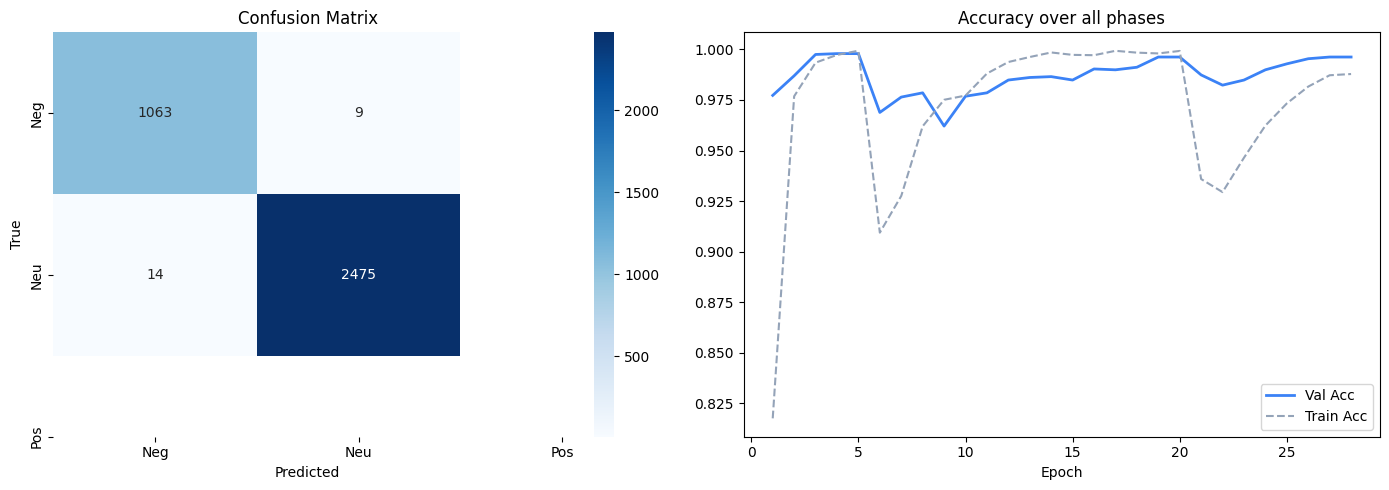

Final Test Accuracy : 99.35%
Final Macro F1      : 99.23%


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 15 — Final evaluation on held-out test set
# ══════════════════════════════════════════════════════════════════
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        xb, yb = batch[0].to(DEVICE), batch[1]
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

print('=== Classification Report ===')
print(classification_report(
    all_labels, all_preds,
    labels=[0, 1, 2],                          # ← add this
    target_names=['Negative','Neutral','Positive'],
    zero_division=0                            # ← avoids warnings for empty classes
))

cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Neu','Pos'],
            yticklabels=['Neg','Neu','Pos'], ax=axes[0])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Flatten all history epochs for loss curve
all_tr_loss = [v for h in all_hist for v in h['tr_loss']]
all_vl_loss = [v for h in all_hist for v in h['vl_loss']]
all_tr_acc  = [v for h in all_hist for v in h['tr_acc']]
all_vl_acc  = [v for h in all_hist for v in h['vl_acc']]
ep = range(1, len(all_tr_loss)+1)

axes[1].plot(ep, all_vl_acc, color='#3b82f6', label='Val Acc', linewidth=2)
axes[1].plot(ep, all_tr_acc, color='#94a3b8', label='Train Acc', linestyle='--')
axes[1].set_title('Accuracy over all phases')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

FINAL_ACC = round(accuracy_score(all_labels, all_preds) * 100, 2)
FINAL_F1  = round(f1_score(all_labels, all_preds, average='macro') * 100, 2)
print(f'Final Test Accuracy : {FINAL_ACC}%')
print(f'Final Macro F1      : {FINAL_F1}%')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 16 — Inference: score every tweet in the dataset
# ══════════════════════════════════════════════════════════════════
@torch.no_grad()
def score_all(model, df):
    model.eval()
    enc  = list(df['tokens'].apply(encode))
    X    = torch.tensor(enc, dtype=torch.long)
    labels, probs_all = [], []
    for i in tqdm(range(0, len(X), CFG['batch_size']*4), desc='Scoring'):
        xb = X[i:i+CFG['batch_size']*4].to(DEVICE)
        p  = torch.softmax(model(xb), dim=-1).cpu().numpy()
        labels.extend(p.argmax(axis=1))
        probs_all.extend(p)
    probs_all = np.array(probs_all)
    out = df.copy().reset_index(drop=True)
    out['pred_label']  = labels
    out['pred_name']   = [LABEL_MAP[l] for l in labels]
    out['prob_neg']    = probs_all[:, 0].round(4)
    out['prob_neu']    = probs_all[:, 1].round(4)
    out['prob_pos']    = probs_all[:, 2].round(4)
    out['confidence']  = probs_all.max(axis=1).round(4)
    out['score']       = ((out['prob_pos'] - out['prob_neg']) * 100).round(1)
    return out

df_scored = score_all(model, df)
print(df_scored[['ticker','text','pred_name','score','confidence']].head(10).to_string())

Scoring:   0%|          | 0/120 [00:00<?, ?it/s]

  ticker                                                                                                                                                                                                                                                                                                                                 text pred_name      score  confidence
0   TSLA                                                 Mainstream media has done an amazing job at brainwashing people. Today at work, we were asked what companies we believe in & I said @Tesla because they make the safest cars & EVERYONE disagreed with me because they heard“they catch on fire & the batteries cost 20k to replace”  Positive  96.300003      0.9744
1   TSLA                                                                                                                                                                                                                                                                 T

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 17 — Aggregate per-stock statistics
# ══════════════════════════════════════════════════════════════════
def aggregate_stock(grp):
    vc  = grp['pred_name'].value_counts(normalize=True).to_dict()
    top_pos = grp[grp['pred_name']=='Positive'].nlargest(5, 'confidence')[['text','score','confidence']].to_dict('records')
    top_neg = grp[grp['pred_name']=='Negative'].nlargest(5, 'confidence')[['text','score','confidence']].to_dict('records')
    recent  = grp.head(8)[['text','pred_name','score','confidence']].to_dict('records')
    return {
        'tweet_count':       len(grp),
        'avg_score':         round(grp['score'].mean(), 1),
        'median_score':      round(grp['score'].median(), 1),
        'positive':          round(vc.get('Positive', 0)*100, 1),
        'neutral':           round(vc.get('Neutral',  0)*100, 1),
        'negative':          round(vc.get('Negative', 0)*100, 1),
        'avg_confidence':    round(grp['confidence'].mean(), 3),
        'top_positive':      top_pos,
        'top_negative':      top_neg,
        'recent_tweets':     recent,
    }

stock_stats = []
for ticker, grp in df_scored.groupby('ticker'):
    stats = aggregate_stock(grp)
    stats['ticker'] = ticker
    stock_stats.append(stats)

stock_stats.sort(key=lambda x: x['avg_score'], reverse=True)

print(f'{"Ticker":8s} {"Avg":>7s} {"Pos%":>7s} {"Neu%":>7s} {"Neg%":>7s} {"Tweets":>8s}')
print('-'*50)
for s in stock_stats:
    print(f'{s["ticker"]:8s} {s["avg_score"]:>7.1f} {s["positive"]:>7.1f} '
          f'{s["neutral"]:>7.1f} {s["negative"]:>7.1f} {s["tweet_count"]:>8,}')

Ticker       Avg    Pos%    Neu%    Neg%   Tweets
--------------------------------------------------
XPEV        77.3    90.8     0.0     9.2       98
BX          77.0    91.7     0.0     8.3       24
F           74.3    88.5     0.0    11.5       26
KO          64.9    83.6     0.0    16.4      134
NIO         62.7    82.9     0.0    17.1    2,406
COST        56.6    79.8     0.0    20.2      213
VZ          51.1    77.3     0.0    22.7       44
MSFT        50.9    76.7     0.0    23.3    3,132
ENPH        50.3    76.2     0.0    23.8      130
DIS         46.4    74.5     0.0    25.5      404
ZS          46.2    74.6     0.0    25.4      126
INTC        44.0    73.4     0.0    26.6      124
AMD         43.8    73.2     0.0    26.8    1,484
GOOG        41.8    72.6     0.0    27.4      705
CRM         41.4    71.9     0.0    28.1      121
BA          36.9    69.6     0.0    30.4      158
TSM         36.7    69.6     0.0    30.4    9,636
AAPL        36.3    69.3     0.0    30.7    2,873

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 22 — Quick inference on custom text
# ══════════════════════════════════════════════════════════════════
@torch.no_grad()
def predict(text: str) -> dict:
    model.eval()
    tokens = tokenize(clean(text))
    enc    = torch.tensor([encode(tokens)], dtype=torch.long).to(DEVICE)
    probs  = torch.softmax(model(enc), dim=-1).cpu().numpy()[0]
    pred   = int(probs.argmax())
    return {
        'text':       text,
        'sentiment':  LABEL_MAP[pred],
        'score':      round((probs[2] - probs[0]) * 100, 1),
        'confidence': round(float(probs.max()) * 100, 1),
        'probs':      {'neg': round(float(probs[0])*100,1),
                       'neu': round(float(probs[1])*100,1),
                       'pos': round(float(probs[2])*100,1)},
    }

samples = [
    '$NVDA absolutely crushing it — monster earnings beat, record revenue. BUY!',
    'Worried about $META layoffs and declining ad revenue. Selling my position.',
    '$AAPL announces new iPhone. Analysts say in-line with expectations.',
    '$TSLA cutting prices again — good for volume but terrible for margins.',
    '$AMZN AWS growth reaccelerating. This is what the bulls have been waiting for.',
    '$NIO delivery numbers disappointing again. Competition from BYD is brutal.',
]

print(f'{"Sentiment":10s} {"Score":>7s} {"Conf%":>7s}  Text')
print('-'*80)
for s in samples:
    r = predict(s)
    print(f'{r["sentiment"]:10s} {r["score"]:>7.1f} {r["confidence"]:>6.1f}%  {s[:65]}')

Sentiment    Score   Conf%  Text
--------------------------------------------------------------------------------
Positive      96.5   97.5%  $NVDA absolutely crushing it — monster earnings beat, record reve
Negative     -96.1   97.3%  Worried about $META layoffs and declining ad revenue. Selling my 
Positive      96.3   97.4%  $AAPL announces new iPhone. Analysts say in-line with expectation
Negative     -64.3   81.3%  $TSLA cutting prices again — good for volume but terrible for mar
Positive      96.4   97.5%  $AMZN AWS growth reaccelerating. This is what the bulls have been
Positive      96.2   97.4%  $NIO delivery numbers disappointing again. Competition from BYD i
